Import & Load Dataset

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

RANDOM_STATE = 42

# Load dataset
df = pd.read_csv("/content/Behavioral_Analytics_Dataset_200_Respondents.csv")
df.head()

,Name,Age_Group,Education,Experience,Organization_Type,Salary_Range,Exp_JobRole,Exp_Salary,Exp_Environment,Exp_Growth,...,Beh_Communication,Beh_PerformancePressure,Adapt_NewTasks,Adapt_LearnSkills,Adapt_HandleChange,Adapt_Anxiety,Adapt_MentalPreparedness,Overall_Satisfaction,Expectation_Met,LongTerm_Intention
0,Manoj Desai,24-26,Undergraduate,<1 year,Product-based,>70000,1,3,2,2,...,2,3,1,1,1,4,2,2,2,2
1,Siddharth Rao,Above 26,Undergraduate,1-2 years,Government,<20000,5,5,4,1,...,5,2,1,5,5,5,1,1,5,4
2,Ishita Verma,Above 26,Postgraduate,2-5 years,MNC,40000-70000,1,3,4,5,...,2,4,1,4,4,5,1,1,1,5
3,Karthik Iyer,21-23,Postgraduate,<1 year,Startup,>70000,4,1,1,5,...,1,3,4,1,2,5,3,5,1,2
4,Arjun Sharma,24-26,Undergraduate,<1 year,Service-based,<20000,3,3,1,1,...,4,1,5,4,3,1,4,4,4,3


Basic Data Understanding

In [8]:
print("\nDataset shape (rows, columns):", df.shape)

print("\nInfo:")
print(df.info())

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nDescriptive statistics (numeric columns):")
print(df.describe())

# Identify categorical & numerical columns
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("\nCategorical columns:", categorical_cols)
print("Numerical columns:", numeric_cols)


Dataset shape (rows, columns): (200, 29)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Name                      200 non-null    object
 1   Age_Group                 200 non-null    object
 2   Education                 200 non-null    object
 3   Experience                200 non-null    object
 4   Organization_Type         200 non-null    object
 5   Salary_Range              200 non-null    object
 6   Exp_JobRole               200 non-null    int64 
 7   Exp_Salary                200 non-null    int64 
 8   Exp_Environment           200 non-null    int64 
 9   Exp_Growth                200 non-null    int64 
 10  Exp_ManagerSupport        200 non-null    int64 
 11  Sat_JobRole               200 non-null    int64 
 12  Sat_Salary                200 non-null    int64 
 13  Sat_Environment           200 n

Data Cleaning & Feature Engineering

Drop unnecessary column

In [9]:
# Remove Name (not useful for modeling)
if "Name" in df.columns:
    df = df.drop(columns=["Name"])

Handle Missing Values

In [11]:
# Re-identify categorical & numerical columns to ensure they are up-to-date
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
df[categorical_cols] = df[categorical_cols].fillna("Unknown")

Create Behavioral Gap Features (Core to Your Problem)

In [12]:
# Expectation score (college expectations)
df["Expectation_Score"] = df[
    ["Exp_JobRole", "Exp_Salary", "Exp_Environment", "Exp_Growth", "Exp_ManagerSupport"]
].mean(axis=1)

# Satisfaction score (workplace reality)
df["Satisfaction_Score"] = df[
    ["Sat_JobRole", "Sat_Salary", "Sat_Environment", "Sat_Growth", "Sat_ManagerSupport"]
].mean(axis=1)

# Expectation Gap
df["Expectation_Gap"] = df["Expectation_Score"] - df["Satisfaction_Score"]

Define Target Variable

In [13]:
df["LongTerm_Intention_flag"] = (df["LongTerm_Intention"] >= 4).astype(int)

Exploratory Data Analysis (EDA)

In [14]:
correlations = df.corr(numeric_only=True)["LongTerm_Intention_flag"].abs().sort_values(ascending=False)
print("Top 10 features correlated with LongTerm Intention:\n", correlations[1:11])

Top 10 features correlated with LongTerm Intention:
 LongTerm_Intention    0.851673
Beh_Communication     0.232232
Beh_Stress            0.191364
Beh_Discipline        0.136897
Sat_Salary            0.127785
Sat_JobRole           0.127592
Expectation_Score     0.124263
Exp_Salary            0.122828
Exp_ManagerSupport    0.092128
Satisfaction_Score    0.083750
Name: LongTerm_Intention_flag, dtype: float64


Expectation Gap vs LongTerm Intention

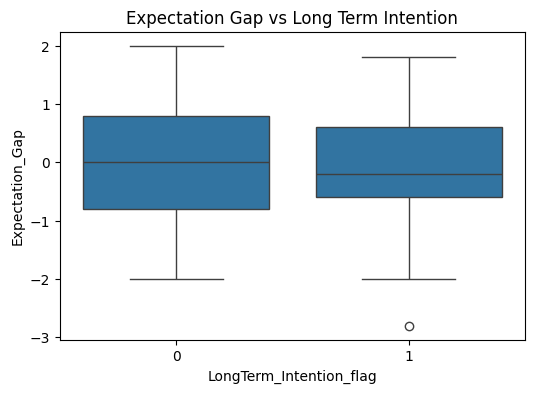

In [15]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="LongTerm_Intention_flag", y="Expectation_Gap")
plt.title("Expectation Gap vs Long Term Intention")
plt.show()

Adaptability vs Satisfaction

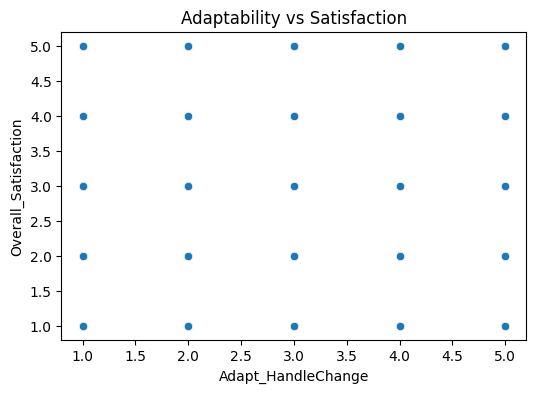

In [16]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="Adapt_HandleChange", y="Overall_Satisfaction")
plt.title("Adaptability vs Satisfaction")
plt.show()

Long Term Intention Distribution

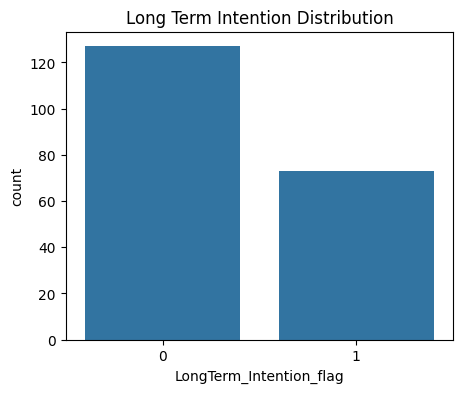

In [17]:
plt.figure(figsize=(5,4))
sns.countplot(data=df, x="LongTerm_Intention_flag")
plt.title("Long Term Intention Distribution")
plt.show()

Feature Selection & Modeling

In [18]:
X = df.drop(columns=["LongTerm_Intention", "LongTerm_Intention_flag"])
y = df["LongTerm_Intention_flag"]

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

Preprocessing Pipeline

In [19]:
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

Train-Test Split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

Behavioral Prediction Models

In [21]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
}

results = {}

for name, model in models.items():

    pipe = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:,1]

    results[name] = {
        "pipeline": pipe,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba)
    }

print("\nModel Evaluation Results:")
for name, res in results.items():
    print(f"\n{name}")
    print(f"Accuracy: {res['accuracy']:.3f}")
    print(f"Precision: {res['precision']:.3f}")
    print(f"Recall: {res['recall']:.3f}")
    print(f"F1 Score: {res['f1']:.3f}")
    print(f"ROC AUC: {res['roc_auc']:.3f}")


Model Evaluation Results:

Logistic Regression
Accuracy: 0.625
Precision: 0.500
Recall: 0.333
F1 Score: 0.400
ROC AUC: 0.648

Random Forest
Accuracy: 0.700
Precision: 1.000
Recall: 0.200
F1 Score: 0.333
ROC AUC: 0.700


Confusion Matrix (Best Model)

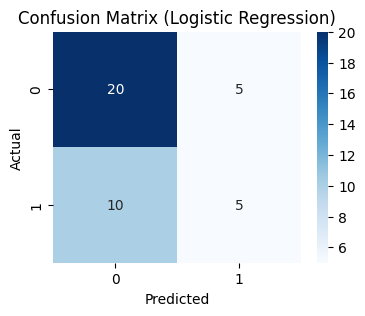

In [22]:
best_model_name = max(results, key=lambda m: results[m]["f1"])
best_pipe = results[best_model_name]["pipeline"]

y_pred_best = best_pipe.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix ({best_model_name})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Behavioral Segmentation (Clustering)

In [23]:
cluster_features = df[
    ["Expectation_Gap", "Overall_Satisfaction",
     "Beh_Stress", "Adapt_HandleChange",
     "Adapt_MentalPreparedness"]
]

scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_features)

kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE)
df["Cluster"] = kmeans.fit_predict(cluster_scaled)

print("\nCluster Counts:")
print(df["Cluster"].value_counts())


Cluster Counts:
Cluster
1    76
2    62
0    62
Name: count, dtype: int64


PCA Visualization

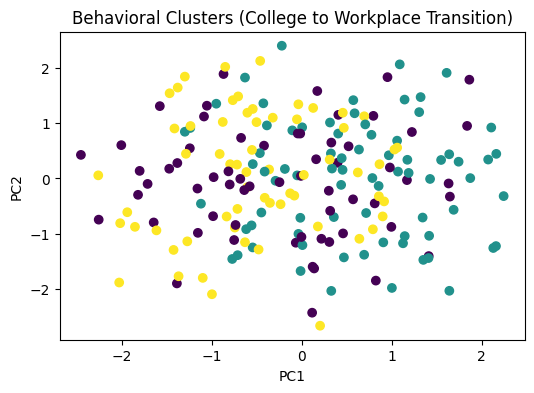

In [24]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
cluster_pca = pca.fit_transform(cluster_scaled)

plt.figure(figsize=(6,4))
plt.scatter(cluster_pca[:,0], cluster_pca[:,1], c=df["Cluster"])
plt.title("Behavioral Clusters (College to Workplace Transition)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

Cluster Profile Interpretation

In [25]:
cluster_profile = df.groupby("Cluster")[[
    "Expectation_Gap",
    "Overall_Satisfaction",
    "Beh_Stress",
    "Adapt_HandleChange",
    "LongTerm_Intention_flag"
]].mean()

print("\nCluster Profiles:")
print(cluster_profile)


Cluster Profiles:
         Expectation_Gap  Overall_Satisfaction  Beh_Stress  \
Cluster                                                      
0               0.661290              2.354839    2.403226   
1              -0.150000              2.986842    4.539474   
2              -0.690323              3.758065    2.112903   

         Adapt_HandleChange  LongTerm_Intention_flag  
Cluster                                               
0                  3.467742                 0.403226  
1                  2.815789                 0.289474  
2                  2.887097                 0.419355  


Key Behavioral Insights

In [26]:
print("\nAverage Expectation Gap by Intention:")
print(df.groupby("LongTerm_Intention_flag")["Expectation_Gap"].mean())

print("\nAverage Stress by Intention:")
print(df.groupby("LongTerm_Intention_flag")["Beh_Stress"].mean())

print("\nAverage Adaptability by Intention:")
print(df.groupby("LongTerm_Intention_flag")["Adapt_HandleChange"].mean())


Average Expectation Gap by Intention:
LongTerm_Intention_flag
0   -0.085039
1   -0.032877
Name: Expectation_Gap, dtype: float64

Average Stress by Intention:
LongTerm_Intention_flag
0    3.322835
1    2.780822
Name: Beh_Stress, dtype: float64

Average Adaptability by Intention:
LongTerm_Intention_flag
0    3.039370
1    3.041096
Name: Adapt_HandleChange, dtype: float64


In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Install scikit-fuzzy if not already installed
!pip install scikit-fuzzy
import skfuzzy as fuzz

RANDOM_STATE = 42

# Select ONLY behavioral transition features
behavioral_features = [
    "Expectation_Gap",
    "Overall_Satisfaction",
    "Beh_Stress",
    "Adapt_HandleChange",
    "Adapt_MentalPreparedness",
    "LongTerm_Intention"
]

numeric_df = df[behavioral_features].copy()

# Handle missing values
numeric_df = numeric_df.fillna(numeric_df.mean())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 34.3 MB/s eta 0:00:00


Standardization

In [31]:
scaler = StandardScaler()
X = scaler.fit_transform(numeric_df)

K-MEANS CLUSTERING

In [32]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X)

labels = kmeans.labels_
centroids = kmeans.cluster_centers_

2D Visualization (PCA Projection)

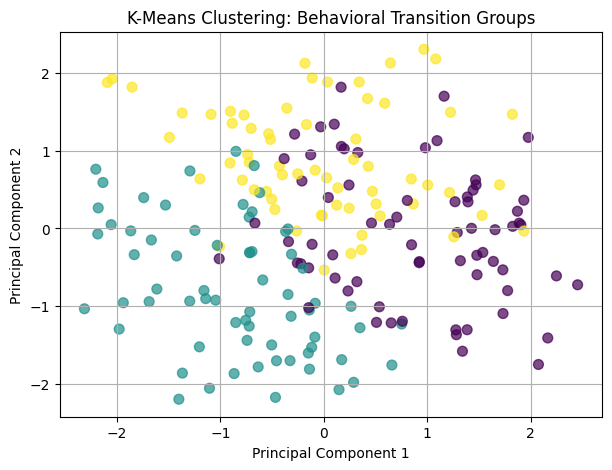

In [33]:
pca = PCA(n_components=2, random_state=42)
X2 = pca.fit_transform(X)

plt.figure(figsize=(7,5))
plt.scatter(X2[:, 0], X2[:, 1], c=labels, cmap='viridis', s=50, alpha=0.7)
plt.title('K-Means Clustering: Behavioral Transition Groups')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

Centroids

In [34]:
print("\nK-Means Cluster Centroids (Standardized Scale):")
print(pd.DataFrame(centroids, columns=behavioral_features))


K-Means Cluster Centroids (Standardized Scale):
   Expectation_Gap  Overall_Satisfaction  Beh_Stress  Adapt_HandleChange  \
0         0.178182             -0.655096   -0.740002           -0.384243   
1        -0.374599              0.315792    0.346156            0.275825   
2         0.200055              0.375681    0.435432            0.125507   

   Adapt_MentalPreparedness  LongTerm_Intention  
0                 -0.267020            0.356909  
1                 -0.601366           -0.799071  
2                  0.917436            0.451735  


Add Cluster Labels to Dataset

In [35]:
df['KMeans_Cluster'] = labels

print("\nIndividual Behavioral Pattern (First 10 Rows):")
print(df.head(10))


Individual Behavioral Pattern (First 10 Rows):
  Age_Group      Education Experience Organization_Type Salary_Range  \
0     24-26  Undergraduate    <1 year     Product-based       >70000   
1  Above 26  Undergraduate  1-2 years        Government       <20000   
2  Above 26   Postgraduate  2-5 years               MNC  40000-70000   
3     21-23   Postgraduate    <1 year           Startup       >70000   
4     24-26  Undergraduate    <1 year     Service-based       <20000   
5  Above 26   Postgraduate  1-2 years           Startup       >70000   
6     24-26  Undergraduate  2-5 years     Product-based  40000-70000   
7     24-26  Undergraduate  1-2 years     Service-based       >70000   
8     24-26   Postgraduate  1-2 years        Government  20000-40000   
9     24-26   Postgraduate  1-2 years     Product-based  40000-70000   

   Exp_JobRole  Exp_Salary  Exp_Environment  Exp_Growth  Exp_ManagerSupport  \
0            1           3                2           2                   1   
1

Cluster-wise Behavioral Pattern

In [36]:
cluster_summary = numeric_df.copy()
cluster_summary['Cluster'] = labels

print("\nGrouped Behavioral Pattern (Cluster-wise Mean):")
print(cluster_summary.groupby('Cluster').mean())


Grouped Behavioral Pattern (Cluster-wise Mean):
         Expectation_Gap  Overall_Satisfaction  Beh_Stress  \
Cluster                                                      
0               0.098551              2.101449    2.115942   
1              -0.411940              3.477612    3.597015   
2               0.118750              3.562500    3.718750   

         Adapt_HandleChange  Adapt_MentalPreparedness  LongTerm_Intention  
Cluster                                                                    
0                  2.492754                  2.449275            3.492754  
1                  3.432836                  1.985075            1.880597  
2                  3.218750                  4.093750            3.625000  


FUZZY C-MEANS CLUSTERING

In [37]:
# Transpose for skfuzzy (features x samples)
X_fuzzy = X.T

n_clusters = 3
m = 2  # fuzziness parameter

Apply Fuzzy C-Means

In [38]:
cntr, u, _, _, _, _, fpc = fuzz.cmeans(
    X_fuzzy,
    c=n_clusters,
    m=m,
    error=0.005,
    maxiter=1000,
    init=None
)

# Hard cluster assignment
fuzzy_labels = np.argmax(u, axis=0)

Fuzzy 2D Visualization

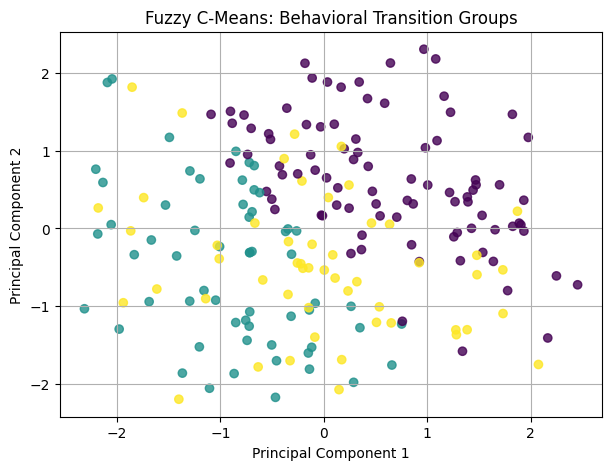

In [39]:
plt.figure(figsize=(7,5))
plt.scatter(X2[:,0], X2[:,1], c=fuzzy_labels, alpha=0.8)
plt.title("Fuzzy C-Means: Behavioral Transition Groups")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()

Fuzzy Centroids

In [40]:
print("\nFuzzy C-Means Cluster Centroids (Standardized Scale):")
print(pd.DataFrame(cntr, columns=behavioral_features))

print("\nFuzzy Partition Coefficient (FPC):", fpc)


Fuzzy C-Means Cluster Centroids (Standardized Scale):
   Expectation_Gap  Overall_Satisfaction  Beh_Stress  Adapt_HandleChange  \
0         0.002216              0.000907   -0.001694           -0.000051   
1        -0.001505              0.001241    0.001641            0.000603   
2        -0.000713             -0.002148    0.000053           -0.000551   

   Adapt_MentalPreparedness  LongTerm_Intention  
0                  0.003004            0.003202  
1                 -0.000669           -0.001786  
2                 -0.002337           -0.001417  

Fuzzy Partition Coefficient (FPC): 0.3333342181772595


Individual Membership Degrees

In [41]:
membership_df = pd.DataFrame(
    u.T,
    columns=[f'Cluster_{i}_Membership' for i in range(n_clusters)]
)

membership_df['Dominant_Cluster'] = fuzzy_labels

individual_behavior = pd.concat([df, membership_df], axis=1)

print("\nIndividual Behavioral Pattern with Membership (First 10 Rows):")
print(individual_behavior.head(10))


Individual Behavioral Pattern with Membership (First 10 Rows):
  Age_Group      Education Experience Organization_Type Salary_Range  \
0     24-26  Undergraduate    <1 year     Product-based       >70000   
1  Above 26  Undergraduate  1-2 years        Government       <20000   
2  Above 26   Postgraduate  2-5 years               MNC  40000-70000   
3     21-23   Postgraduate    <1 year           Startup       >70000   
4     24-26  Undergraduate    <1 year     Service-based       <20000   
5  Above 26   Postgraduate  1-2 years           Startup       >70000   
6     24-26  Undergraduate  2-5 years     Product-based  40000-70000   
7     24-26  Undergraduate  1-2 years     Service-based       >70000   
8     24-26   Postgraduate  1-2 years        Government  20000-40000   
9     24-26   Postgraduate  1-2 years     Product-based  40000-70000   

   Exp_JobRole  Exp_Salary  Exp_Environment  Exp_Growth  Exp_ManagerSupport  \
0            1           3                2           2         

Fuzzy Cluster-wise Behavioral Pattern

In [42]:
grouped_behavior = numeric_df.copy()
grouped_behavior['Cluster'] = fuzzy_labels

print("\nFuzzy Grouped Behavioral Pattern (Cluster-wise Mean):")
print(grouped_behavior.groupby('Cluster').mean())


Fuzzy Grouped Behavioral Pattern (Cluster-wise Mean):
         Expectation_Gap  Overall_Satisfaction  Beh_Stress  \
Cluster                                                      
0               0.247727              3.238636    2.738636   
1              -0.430000              3.866667    3.700000   
2              -0.176923              1.711538    3.115385   

         Adapt_HandleChange  Adapt_MentalPreparedness  LongTerm_Intention  
Cluster                                                                    
0                  3.034091                  3.625000            3.852273  
1                  3.500000                  2.433333            2.050000  
2                  2.519231                  1.903846            2.634615  


CLUSTER EVALUATION

In [43]:
print("\nKMeans Evaluation Metrics")
print("Silhouette Score:", silhouette_score(X, labels))
print("Davies-Bouldin Index:", davies_bouldin_score(X, labels))
print("Calinski-Harabasz Score:", calinski_harabasz_score(X, labels))

print("\nFuzzy C-Means Evaluation Metrics")
print("Silhouette Score:", silhouette_score(X, fuzzy_labels))
print("Davies-Bouldin Index:", davies_bouldin_score(X, fuzzy_labels))
print("Calinski-Harabasz Score:", calinski_harabasz_score(X, fuzzy_labels))

print("Fuzzy Partition Coefficient (FPC):", fpc)


KMeans Evaluation Metrics
Silhouette Score: 0.13361182211068384
Davies-Bouldin Index: 2.0490573902357307
Calinski-Harabasz Score: 30.16948646901205

Fuzzy C-Means Evaluation Metrics
Silhouette Score: 0.10231683232017019
Davies-Bouldin Index: 2.2530222994503677
Calinski-Harabasz Score: 24.642128078521733
Fuzzy Partition Coefficient (FPC): 0.3333342181772595


Install Dependencies

In [44]:
!pip install semopy pingouin scikit-learn matplotlib seaborn pandas numpy scipy statsmodels scikit-fuzzy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 34.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.8/204.8 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.3/94.3 kB 8.4 MB/s eta 0:00:00
  Created wheel for semopy: filename=semopy-2.3.11-py3-none-any.whl size=1659682 sha256=af5eaf3f9bfece188713f1259250a4465c58f21bb391e28eb74f543a7c92e257
  Stored in directory: /root/.cache/pip/wheels/c6/24/8b/be911b059a61f490f38425eb19bf2fed470a5ead97228e8255
Successfully built semopy


Import Libraries

In [45]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from itertools import combinations

In [ ]:
Load Your Dataset

In [46]:
df = pd.read_csv("/content/Behavioral_Analytics_Dataset_200_Respondents.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (200, 29)


,Name,Age_Group,Education,Experience,Organization_Type,Salary_Range,Exp_JobRole,Exp_Salary,Exp_Environment,Exp_Growth,...,Beh_Communication,Beh_PerformancePressure,Adapt_NewTasks,Adapt_LearnSkills,Adapt_HandleChange,Adapt_Anxiety,Adapt_MentalPreparedness,Overall_Satisfaction,Expectation_Met,LongTerm_Intention
0,Manoj Desai,24-26,Undergraduate,<1 year,Product-based,>70000,1,3,2,2,...,2,3,1,1,1,4,2,2,2,2
1,Siddharth Rao,Above 26,Undergraduate,1-2 years,Government,<20000,5,5,4,1,...,5,2,1,5,5,5,1,1,5,4
2,Ishita Verma,Above 26,Postgraduate,2-5 years,MNC,40000-70000,1,3,4,5,...,2,4,1,4,4,5,1,1,1,5
3,Karthik Iyer,21-23,Postgraduate,<1 year,Startup,>70000,4,1,1,5,...,1,3,4,1,2,5,3,5,1,2
4,Arjun Sharma,24-26,Undergraduate,<1 year,Service-based,<20000,3,3,1,1,...,4,1,5,4,3,1,4,4,4,3


Define Constructs (Aligned to Your Study)

In [47]:
constructs = {
    "College_Expectation": [
        "Exp_JobRole", "Exp_Salary", "Exp_Environment",
        "Exp_Growth", "Exp_ManagerSupport"
    ],
    "Workplace_Satisfaction": [
        "Sat_JobRole", "Sat_Salary", "Sat_Environment",
        "Sat_Growth", "Sat_ManagerSupport"
    ],
    "Adaptability": [
        "Adapt_HandleChange", "Adapt_LearningSpeed",
        "Adapt_MentalPreparedness"
    ],
    "Behavioral_Stress": [
        "Beh_Stress", "Beh_WorkPressure",
        "Beh_WorkLifeBalance"
    ],
    "LongTerm_Intention": [
        "LongTerm_Intention", "Overall_Satisfaction"
    ]
}

Define Structural Model (Your Research Model)

In [48]:
structural_paths = [
    ("College_Expectation", "Workplace_Satisfaction"),
    ("Adaptability", "Workplace_Satisfaction"),
    ("Behavioral_Stress", "Workplace_Satisfaction"),
    ("Workplace_Satisfaction", "LongTerm_Intention"),
    ("Adaptability", "LongTerm_Intention")
]

MEASUREMENT MODEL

Reliability & Validity

In [49]:
def cronbach_alpha(data):
    k = data.shape[1]
    if k < 2:
        return np.nan
    var_items = data.var(axis=0, ddof=1).sum()
    var_total = data.sum(axis=1).var(ddof=1)
    return (k / (k - 1)) * (1 - var_items / var_total)

def composite_reliability(loadings):
    sum_l = np.sum(loadings)
    sum_err = np.sum(1 - loadings**2)
    return (sum_l**2) / (sum_l**2 + sum_err)

def avg_variance_extracted(loadings):
    return np.mean(loadings**2)

measurement_results = []
all_loadings = {}
latent_data = {}

for name, items in constructs.items():
    available = [c for c in items if c in df.columns]
    block = df[available].dropna()
    score = block.mean(axis=1)
    loadings = np.array([block[col].corr(score) for col in available])
    all_loadings[name] = dict(zip(available, loadings))

    alpha = cronbach_alpha(block)
    cr = composite_reliability(loadings)
    ave = avg_variance_extracted(loadings)

    measurement_results.append({
        "Construct": name,
        "Items": len(available),
        "Alpha": round(alpha, 3),
        "CR": round(cr, 3),
        "AVE": round(ave, 3),
        "AVE_sqrt": round(np.sqrt(ave), 3),
    })

    latent_data[name] = score

latent_df = pd.DataFrame(latent_data)
meas_df = pd.DataFrame(measurement_results)

print(meas_df.to_string(index=False))

             Construct  Items  Alpha    CR   AVE  AVE_sqrt
   College_Expectation      5  0.017 0.560 0.205     0.453
Workplace_Satisfaction      5 -0.013 0.553 0.199     0.446
          Adaptability      2 -0.179 0.629 0.459     0.677
     Behavioral_Stress      1    NaN 1.000 1.000     1.000
    LongTerm_Intention      2 -0.025 0.661 0.494     0.703


DISCRIMINANT VALIDITY

Fornell-Larcker + HTMT

In [50]:
construct_names = list(constructs.keys())

fl_matrix = pd.DataFrame(index=construct_names, columns=construct_names)

for c in construct_names:
    ave = meas_df.loc[meas_df["Construct"] == c, "AVE"].values[0]
    fl_matrix.loc[c, c] = round(np.sqrt(ave), 3)
    for c2 in construct_names:
        if c != c2:
            fl_matrix.loc[c, c2] = round(latent_df[c].corr(latent_df[c2]), 3)

print("Fornell-Larcker Matrix")
print(fl_matrix)

Fornell-Larcker Matrix
                       College_Expectation Workplace_Satisfaction  \
College_Expectation                  0.453                  -0.06   
Workplace_Satisfaction               -0.06                  0.446   
Adaptability                        -0.061                 -0.108   
Behavioral_Stress                     0.03                  0.029   
LongTerm_Intention                   0.052                 -0.013   

                       Adaptability Behavioral_Stress LongTerm_Intention  
College_Expectation          -0.061              0.03              0.052  
Workplace_Satisfaction       -0.108             0.029             -0.013  
Adaptability                  0.677             0.061              0.112  
Behavioral_Stress             0.061               1.0             -0.103  
LongTerm_Intention            0.112            -0.103              0.703  


STRUCTURAL MODEL (PLS Style via OLS)

In [51]:
def run_ols_path(X_cols, y_col, data):
    X = sm.add_constant(data[X_cols])
    y = data[y_col]
    model = sm.OLS(y, X).fit()
    return model

endogenous = list({tgt for _, tgt in structural_paths})
exo_by_endo = {e: [s for s, t in structural_paths if t == e] for e in endogenous}

path_results = []
r2_scores = {}

for endo, exo_list in exo_by_endo.items():
    model = run_ols_path(exo_list, endo, latent_df)
    r2_scores[endo] = round(model.rsquared, 3)

    for pred in exo_list:
        path_results.append({
            "Path": f"{pred} → {endo}",
            "Beta": round(model.params[pred], 4),
            "t_stat": round(model.tvalues[pred], 3),
            "p_value": round(model.pvalues[pred], 4)
        })

path_df = pd.DataFrame(path_results)
print(path_df)
print("\nR² Values:", r2_scores)

                                           Path    Beta  t_stat  p_value
0   Workplace_Satisfaction → LongTerm_Intention -0.0014  -0.012   0.9902
1             Adaptability → LongTerm_Intention  0.1166   1.578   0.1161
2  College_Expectation → Workplace_Satisfaction -0.0684  -0.955   0.3407
3         Adaptability → Workplace_Satisfaction -0.0764  -1.607   0.1097
4    Behavioral_Stress → Workplace_Satisfaction  0.0178   0.535   0.5930

R² Values: {'LongTerm_Intention': np.float64(0.013), 'Workplace_Satisfaction': np.float64(0.017)}


BOOTSTRAPPING (500 Resamples)

In [52]:
def bootstrap_paths(data, exo_list, endo, n_boot=500):
    coefs = {e: [] for e in exo_list}
    n = len(data)
    for _ in range(n_boot):
        idx = np.random.choice(n, n, replace=True)
        boot = data.iloc[idx]
        X = sm.add_constant(boot[exo_list])
        m = sm.OLS(boot[endo], X).fit()
        for e in exo_list:
            coefs[e].append(m.params[e])
    return coefs

boot_results = []

for endo, exo_list in exo_by_endo.items():
    boot = bootstrap_paths(latent_df, exo_list, endo)
    for pred, vals in boot.items():
        lo, hi = np.percentile(vals, [2.5, 97.5])
        boot_results.append({
            "Path": f"{pred} → {endo}",
            "Beta": round(np.mean(vals), 4),
            "CI_Low": round(lo, 4),
            "CI_High": round(hi, 4)
        })

boot_df = pd.DataFrame(boot_results)
print(boot_df)

                                           Path    Beta  CI_Low  CI_High
0   Workplace_Satisfaction → LongTerm_Intention -0.0070 -0.2233   0.1980
1             Adaptability → LongTerm_Intention  0.1175 -0.0311   0.2800
2  College_Expectation → Workplace_Satisfaction -0.0705 -0.1966   0.0567
3         Adaptability → Workplace_Satisfaction -0.0763 -0.1833   0.0247
4    Behavioral_Stress → Workplace_Satisfaction  0.0188 -0.0456   0.0847


R² Visualization

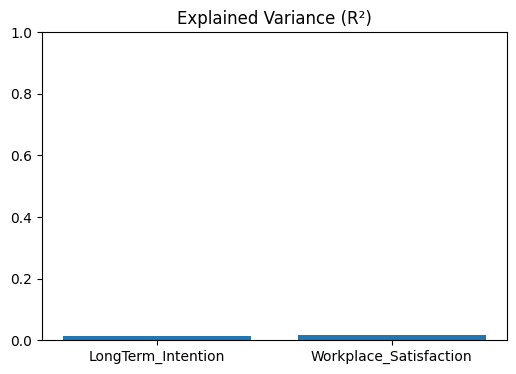

In [53]:
plt.figure(figsize=(6,4))
plt.bar(r2_scores.keys(), r2_scores.values())
plt.ylim(0,1)
plt.title("Explained Variance (R²)")
plt.show()

Latent Correlation Matrix

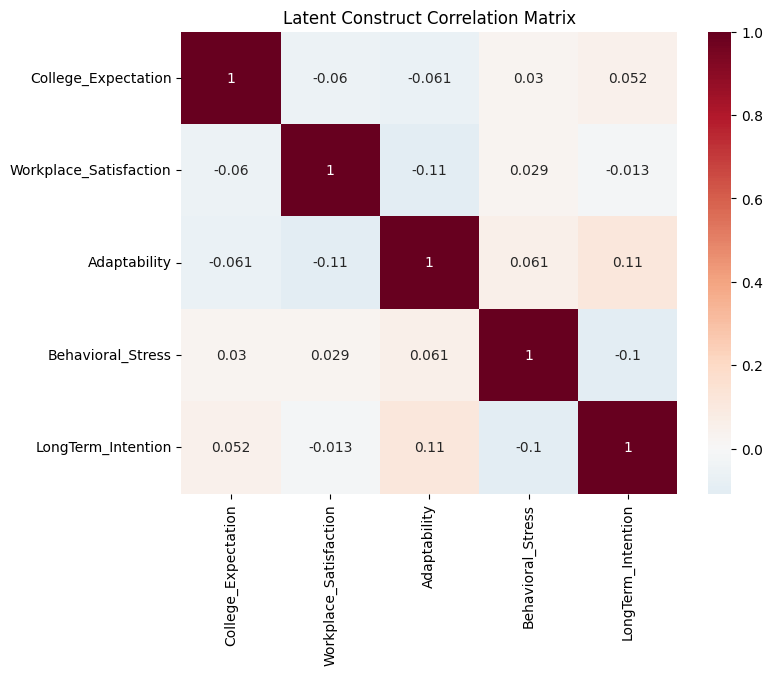

In [54]:
plt.figure(figsize=(8,6))
sns.heatmap(latent_df.corr(), annot=True, cmap="RdBu_r", center=0)
plt.title("Latent Construct Correlation Matrix")
plt.show()

Professional PLS-SEM Path Diagram

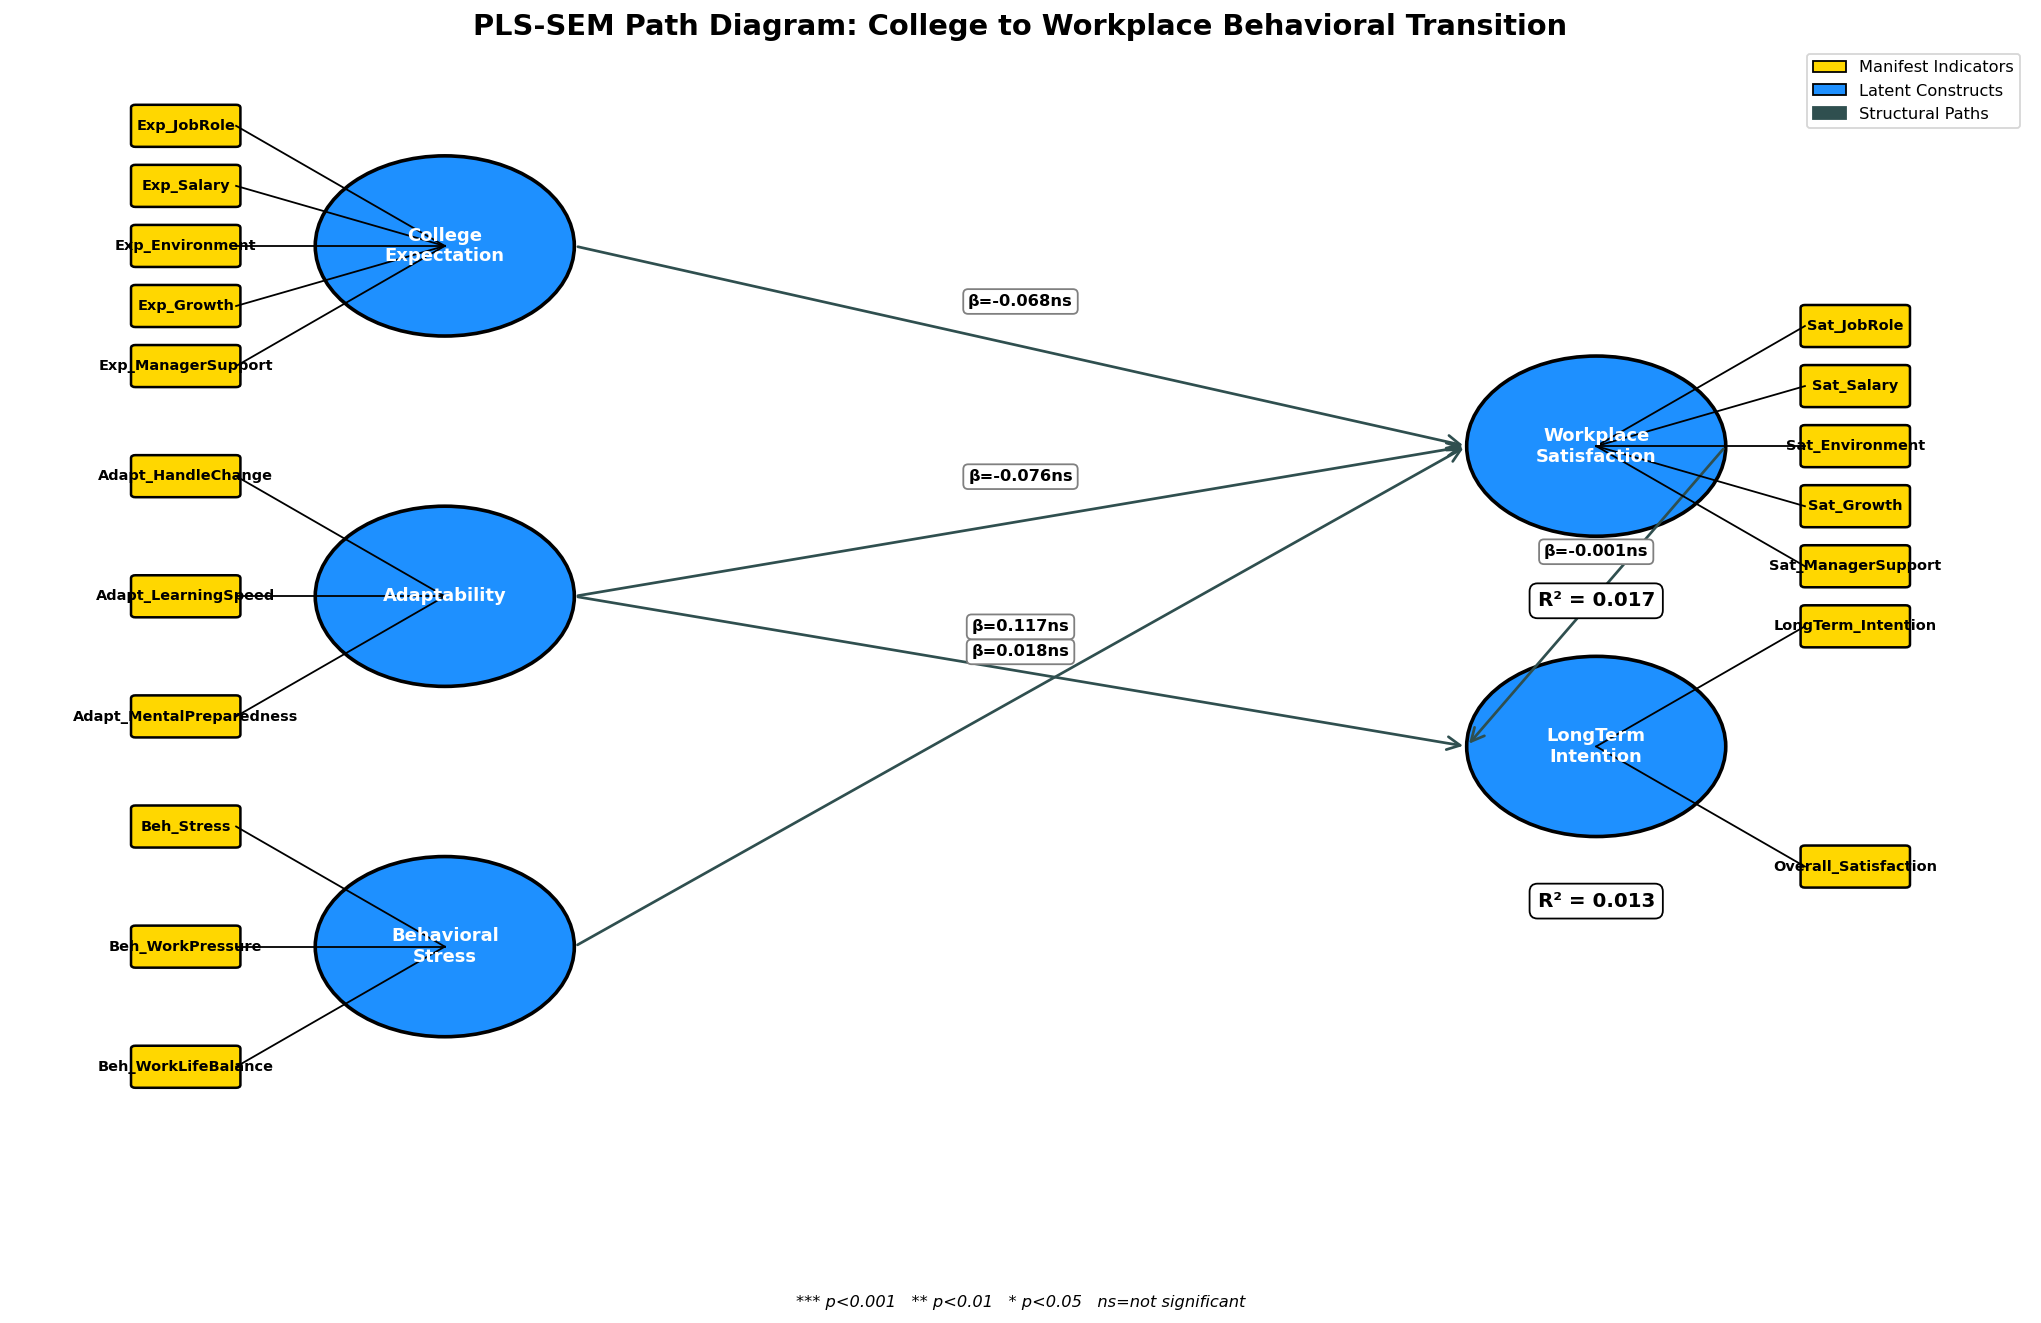

In [55]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, Circle, FancyArrowPatch
import numpy as np

plt.rcParams["figure.dpi"] = 130

fig, ax = plt.subplots(figsize=(20, 12), facecolor='white')
ax.set_xlim(0, 14)
ax.set_ylim(0, 12)
ax.axis('off')

INDICATOR_COLOR = '#FFD700'
CONSTRUCT_COLOR = '#1E90FF'
ARROW_COLOR = '#2F4F4F'

# --------------------------
# Drawing Functions
# --------------------------

def draw_indicator(x, y, label):
    rect = FancyBboxPatch((x-0.35, y-0.18), 0.7, 0.36,
                          boxstyle="round,pad=0.03",
                          facecolor=INDICATOR_COLOR,
                          edgecolor='black',
                          linewidth=1.4)
    ax.add_patch(rect)
    ax.text(x, y, label, ha='center', va='center',
            fontsize=8, fontweight='bold')

def draw_construct(x, y, name):
    circle = Circle((x, y), 0.9,
                    facecolor=CONSTRUCT_COLOR,
                    edgecolor='black',
                    linewidth=2)
    ax.add_patch(circle)
    ax.text(x, y, name.replace("_","\n"),
            ha='center', va='center',
            fontsize=10,
            fontweight='bold',
            color='white')

def draw_path(src, tgt):
    row = path_df[path_df["Path"] == f"{src} → {tgt}"]
    if len(row) == 0:
        return

    beta = row["Beta"].values[0]
    pval = row["p_value"].values[0]

    if pval < 0.001:
        sig = "***"
    elif pval < 0.01:
        sig = "**"
    elif pval < 0.05:
        sig = "*"
    else:
        sig = "ns"

    x1, y1 = positions[src]
    x2, y2 = positions[tgt]

    arrow = FancyArrowPatch((x1+0.9, y1),
                            (x2-0.9, y2),
                            arrowstyle='->',
                            mutation_scale=18,
                            linewidth=max(1.5, abs(beta)*6),
                            color=ARROW_COLOR)
    ax.add_patch(arrow)

    ax.text((x1+x2)/2,
            (y1+y2)/2 + 0.4,
            f"β={beta:.3f}{sig}",
            ha='center',
            fontsize=9,
            fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.3",
                      facecolor='white',
                      edgecolor='gray'))

# --------------------------
# Layout Positions
# --------------------------

exogenous = ["College_Expectation",
             "Adaptability",
             "Behavioral_Stress"]

endogenous = ["Workplace_Satisfaction",
              "LongTerm_Intention"]

positions = {}

left_y = np.linspace(10, 3, len(exogenous))
for i, c in enumerate(exogenous):
    positions[c] = (3, left_y[i])

right_y = np.linspace(8, 5, len(endogenous))
for i, c in enumerate(endogenous):
    positions[c] = (11, right_y[i])

# --------------------------
# Draw Constructs + Indicators
# --------------------------

for construct in constructs:
    x, y = positions[construct]
    draw_construct(x, y, construct)

    items = constructs[construct]
    n = len(items)

    if construct in exogenous:
        ind_x = x - 1.8
    else:
        ind_x = x + 1.8

    ind_y = np.linspace(y+1.2, y-1.2, n)

    for item, iy in zip(items, ind_y):
        draw_indicator(ind_x, iy, item)

        ax.plot([ind_x + (0.35 if construct in exogenous else -0.35), x],
                [iy, y],
                color='black',
                linewidth=1)

# --------------------------
# Draw Structural Paths
# --------------------------

for src, tgt in structural_paths:
    draw_path(src, tgt)

# --------------------------
# Add R² values
# --------------------------

for c in endogenous:
    x, y = positions[c]
    ax.text(x,
            y-1.6,
            f"R² = {r2_scores.get(c, np.nan)}",
            ha='center',
            fontsize=11,
            fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.4",
                      facecolor='white',
                      edgecolor='black'))

# --------------------------
# Title + Legend
# --------------------------

plt.title("PLS-SEM Path Diagram: College to Workplace Behavioral Transition",
          fontsize=16,
          fontweight='bold')

legend_elements = [
    mpatches.Patch(facecolor=INDICATOR_COLOR, edgecolor='black',
                   label='Manifest Indicators'),
    mpatches.Patch(facecolor=CONSTRUCT_COLOR, edgecolor='black',
                   label='Latent Constructs'),
    mpatches.FancyArrow(0,0,0.5,0,width=0.1,
                        color=ARROW_COLOR,
                        label='Structural Paths')
]

ax.legend(handles=legend_elements,
          loc='upper right',
          fontsize=9,
          frameon=True)

ax.text(0.5,-0.05,
        "*** p<0.001   ** p<0.01   * p<0.05   ns=not significant",
        transform=ax.transAxes,
        ha='center',
        fontsize=9,
        style='italic')

plt.show()